In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

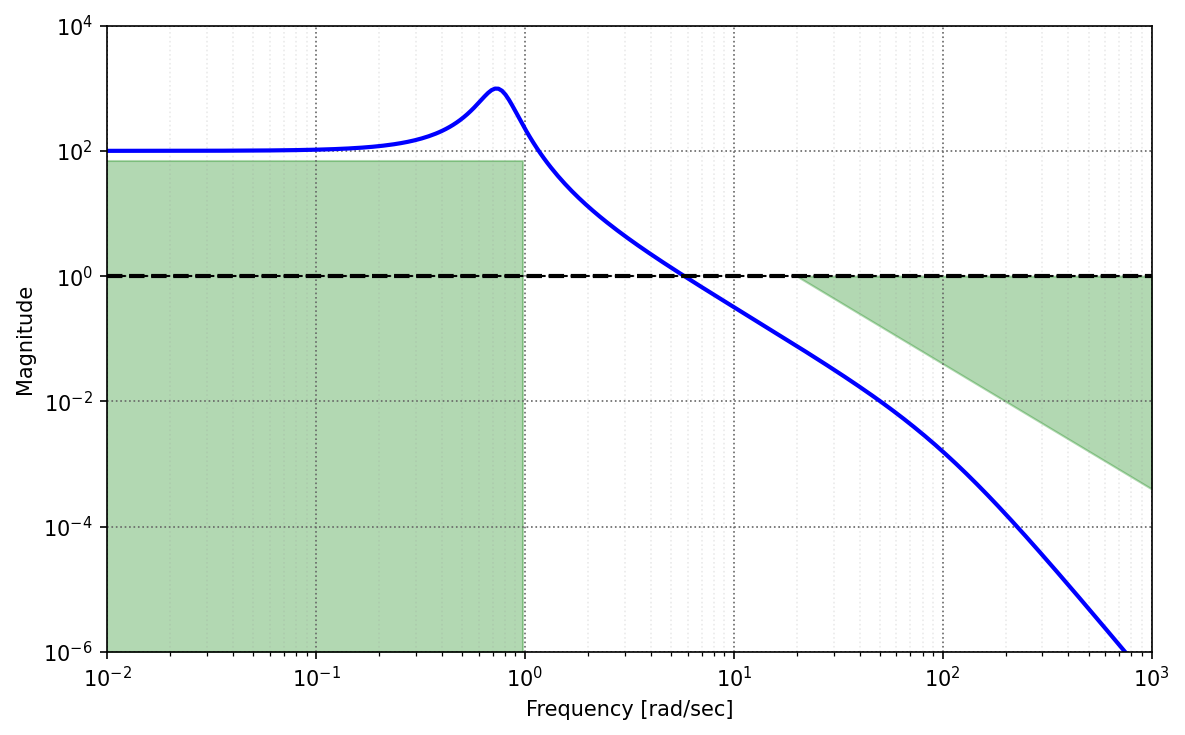

In [4]:
w = np.logspace(-2,3,300)
#zero
wn = .75
w_low = 1 
w_high = 20 
G1 = 100*ct.tf([1/1,1],[1/100,1])**2*ct.tf([wn**2],[1,2*.2*wn,wn**2])**2 
G1f = G1(complex(0,1)*w)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150)
ax.loglog(w,np.abs(G1f),'b-',label='G')
ax.plot([1e-2,1e3],[1,1],color='k',ls='--')
ax.set_ylim([1e-6,1e4])
ax.set_ylabel("Magnitude")
ax.set_xlabel("Frequency [rad/sec]")
plt.fill_between(w[w < w_low], 70, y2=1e-6, color='green', alpha=0.3)
plt.fill_between(w[w > w_high], 1, y2 = (w_high/w[w > w_high])**2, color='green', alpha=0.3)
bm.nicegrid(ax)
plt.savefig('./figs/L17_perf.pdf',dpi=600)
plt.show()